### GPAW and equation of state (eos)

To give you an idea of how the choice of method and basis affects ground-state properties, let us look at the eos for PW vs LCAO. This should prove that comparing absolute DFT numbers is pointless without context.

Before running calculations for a specific system, the DFT setup needs to be defined. One part of this process is to find, for example, the equilibrium lattice parameter(s) from a energy vs volume curve. ASE provides the required [tools](https://ase-lib.org/ase/eos.html#ase.eos.EquationOfState).

In [1]:
import pathlib

import ase.io
import numpy as np

from ase.eos import EquationOfState
from ase.optimize import LBFGS
from gpaw import GPAW, PW
from tqdm.auto import tqdm


# since we use the identical code for both methods,
# it is sensible to define a function
def calculate_eos(atoms, calc, grid=np.linspace(0.95, 1.05, 7)):
    """ Calculate the eos for given atoms and calculator.
    """
    volumes = []
    energies = []
    
    original_cell = atoms.get_cell()
    
    for g in tqdm(grid):
        atoms.set_cell(original_cell * g, scale_atoms=True)
        volumes.append(atoms.get_volume())
        
        # relax the atom positions
        btoms = atoms.copy()
        btoms.calc = calc
        opt = LBFGS(
            btoms,
            trajectory=None,
            logfile=None,
        )
        converged = opt.run(fmax=0.001)
        if converged:
            energies.append(btoms.get_potential_energy())
        else:
            raise Exception("Failed to converge atom positions.")

    eos = EquationOfState(volumes, energies, eos='birchmurnaghan')
    
    v0, e0, B = eos.fit()
    print(f"Equilibrium volume: {v0:.3f} A^3")
    print(f"Bulk Modulus: {B * 160.217:.3f} GPa") # Convert eV/A^3 to GPa

    return eos

A computationally-efficient mode is [Linear Combination of Atomic Orbitals (LCAO)](https://gpaw.readthedocs.io/documentation/lcao/lcao.html#lcao). As for any method, you need to be aware of its limitations.

  0%|          | 0/7 [00:00<?, ?it/s]

Equilibrium volume: 170.207 A^3
Bulk Modulus: 120.412 GPa


<Axes: title={'center': 'birchmurnaghan: E: -49.553 eV, V: 170.207 Å$^3$, B: 120.412 GPa'}, xlabel='volume [Å$^3$]', ylabel='energy [eV]'>

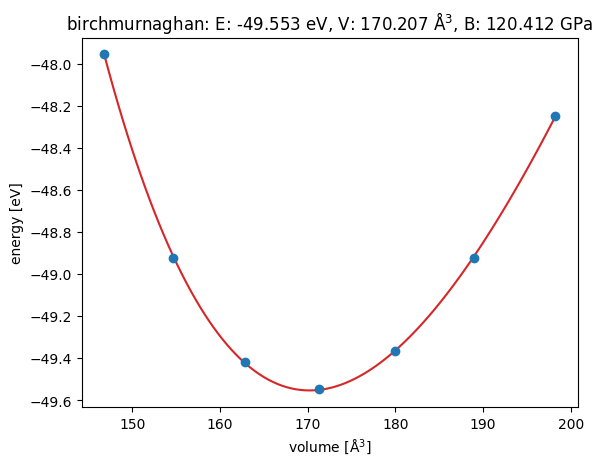

In [2]:
# LCAO mode
atoms = ase.io.read(pathlib.Path.cwd().parents[1]
                    / "data" / "Cu2S_FCC" / "Cu2S_conv.extxyz")

calc = GPAW(mode='lcao',
            basis='dzp',
            txt='gpaw_output.txt',
           )
atoms.calc = calc

eos = calculate_eos(atoms=atoms, calc=calc)
eos.plot()

The GPAW documentation [compares](https://gpaw.readthedocs.io/documentation/basic.html#comparing-pw-lcao-and-fd-modes) the finite differences (FD), LCAO, and plane waves (PW) modes.

For periodic solids, using a plane wave basis is the most typical way people think about "doing DFT".

  0%|          | 0/7 [00:00<?, ?it/s]

Equilibrium volume: 43.889 A^3
Bulk Modulus: 95.957 GPa


<Axes: title={'center': 'birchmurnaghan: E: -11.652 eV, V: 43.889 Å$^3$, B: 95.958 GPa'}, xlabel='volume [Å$^3$]', ylabel='energy [eV]'>

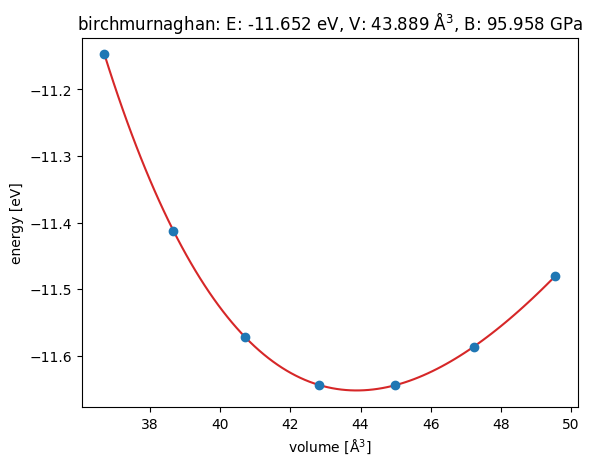

In [3]:
# PW mode
atoms = ase.io.read(pathlib.Path.cwd().parents[1] / "data" / "Cu2S_FCC" / "Cu2S_prim.extxyz")

calc = GPAW(mode=PW(800),
            xc="PBE",
            kpts={'size': (8, 8, 8), 'gamma': True},
            txt='gpaw_output.txt',
           )
atoms.calc = calc

eos = calculate_eos(atoms=atoms, calc=calc)
eos.plot()